In [1]:
import os, json, pickle
import numpy as np

ckpt_dir = "../checkpoints_fused"
fig_dir  = "../figures_fused"
cfg_path = "../configs/default_modality.json"

with open(cfg_path, "r") as f:
    cfg = json.load(f)

times = np.load(os.path.join(ckpt_dir, "times.npy"))

with open(os.path.join(ckpt_dir, "scaler_atac.pkl"), "rb") as f: sc_atac = pickle.load(f)
with open(os.path.join(ckpt_dir, "scaler_hic.pkl"),  "rb") as f: sc_hic  = pickle.load(f)
with open(os.path.join(ckpt_dir, "pca_atac.pkl"),    "rb") as f: pca_atac = pickle.load(f)
with open(os.path.join(ckpt_dir, "pca_hic.pkl"),     "rb") as f: pca_hic  = pickle.load(f)

X_atac = np.load("../" + cfg["data"]["atac_path"]).astype(np.float32)
X_hic  = np.load("../" + cfg["data"]["hic_path"]).astype(np.float32)

X_atac = np.log1p(np.maximum(X_atac, 0.0))
X_hic  = np.log1p(np.maximum(X_hic,  0.0))

X_atac_std = sc_atac.transform(X_atac)
X_hic_std  = sc_hic.transform(X_hic)

X_pred_atac_no = np.load(os.path.join(fig_dir, "X_pred_atac_std_noass.npy"))
X_pred_atac_as = np.load(os.path.join(fig_dir, "X_pred_atac_std_assim.npy"))
X_pred_hic_no  = np.load(os.path.join(fig_dir, "X_pred_hic_std_noass.npy"))
X_pred_hic_as  = np.load(os.path.join(fig_dir, "X_pred_hic_std_assim.npy"))

X_true_fused = np.concatenate([X_atac_std, X_hic_std], axis=1)
X_no_fused   = np.concatenate([X_pred_atac_no, X_pred_hic_no], axis=1)
X_as_fused   = np.concatenate([X_pred_atac_as, X_pred_hic_as], axis=1)

Z_concat = np.load(os.path.join(ckpt_dir, "Z.npy"))
D_atac = pca_atac.components_.shape[0]
D_hic  = pca_hic.components_.shape[0]
Z_true_atac = Z_concat[:, :D_atac]
Z_true_hic  = Z_concat[:, D_atac:D_atac+D_hic]

assim_times = [0.33, 1.0, 4.0]
assim_idx = [np.argmin(np.abs(times - t)) for t in assim_times]


In [2]:
import numpy as np

def rmse(A, B):
    return float(np.sqrt(((A - B) ** 2).mean()))

def r2(A, B):
    num = ((A - B) ** 2).sum()
    den = ((A - A.mean()) ** 2).sum() + 1e-12
    return float(1.0 - num / den)

def r2_timewise(A, B):
    num = ((A - B)**2).sum(axis=1)
    den = ((A - A.mean(axis=1, keepdims=True))**2).sum(axis=1) + 1e-12
    return 1 - num/den

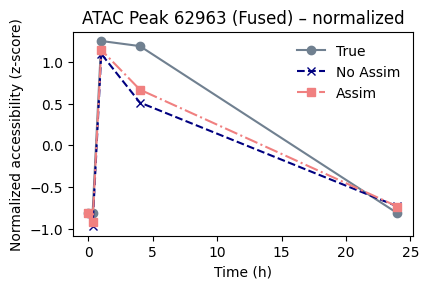

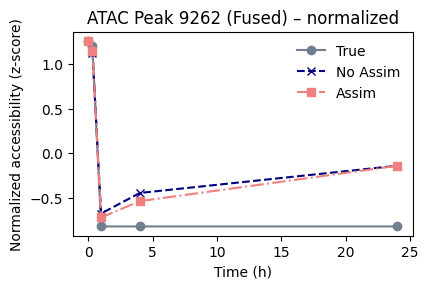

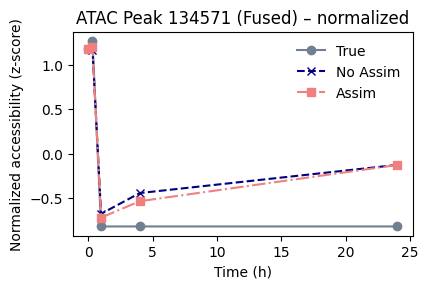

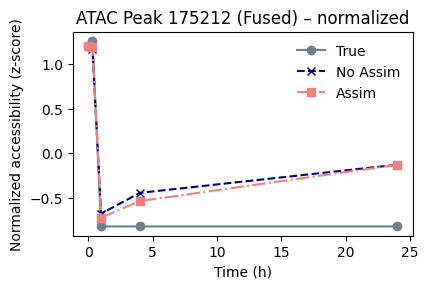

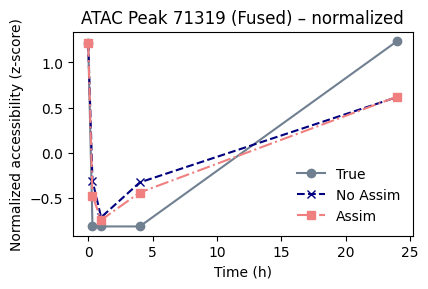

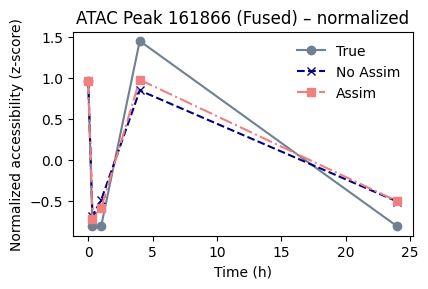

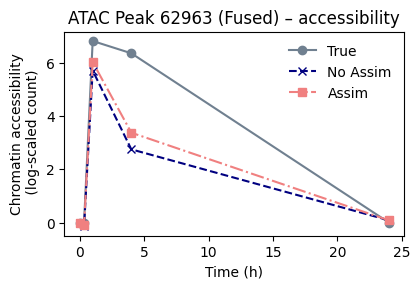

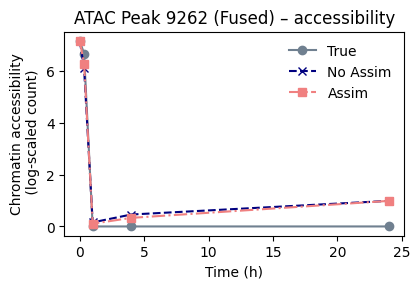

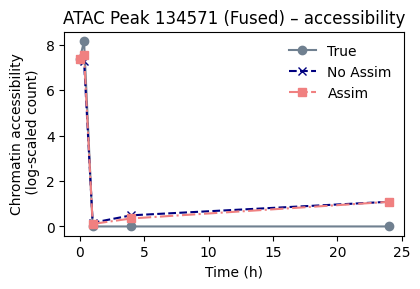

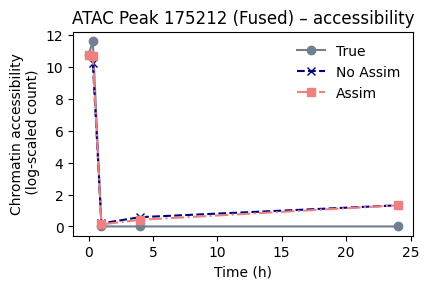

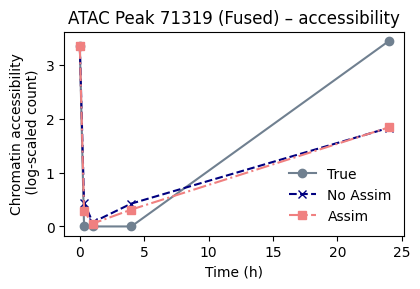

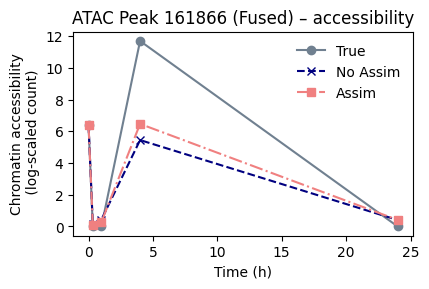

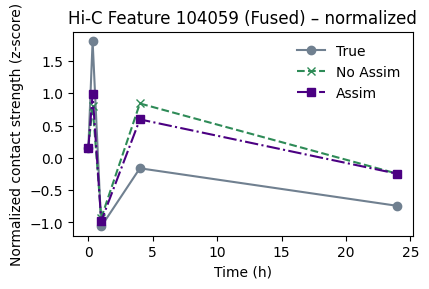

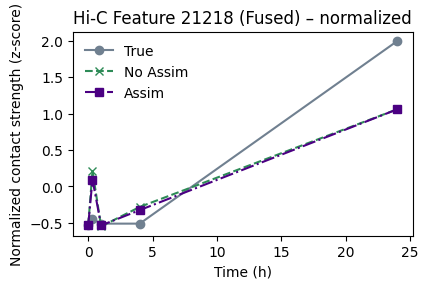

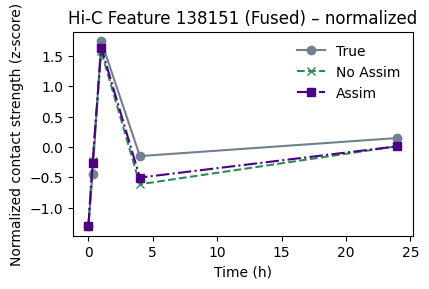

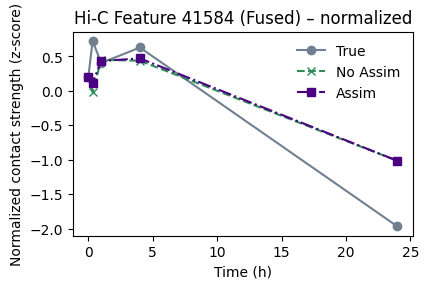

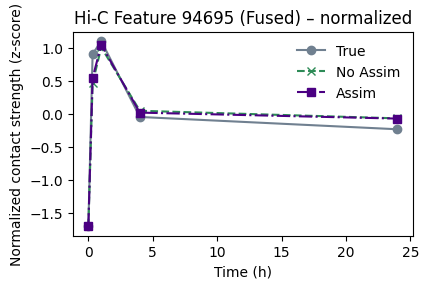

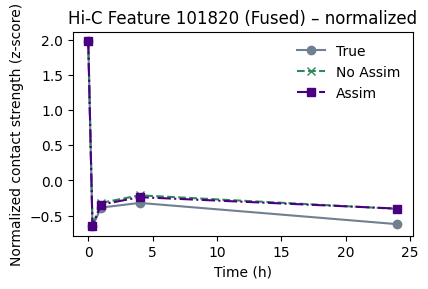

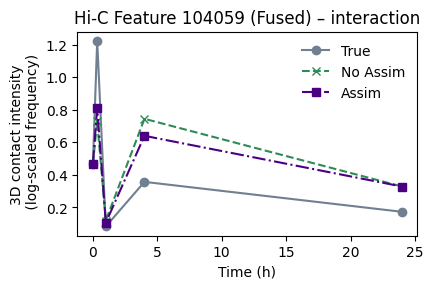

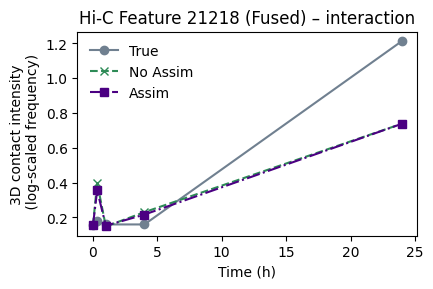

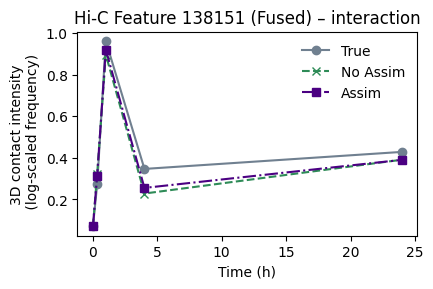

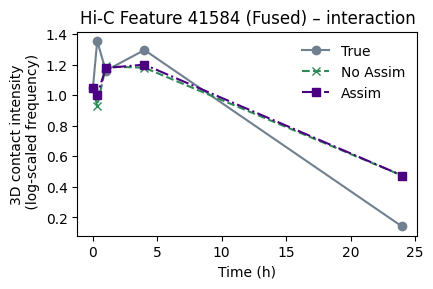

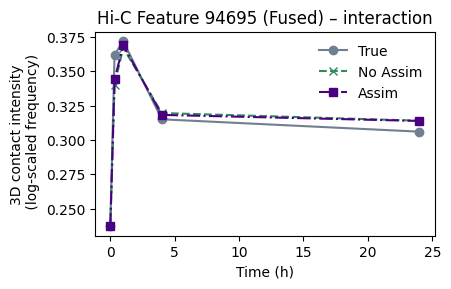

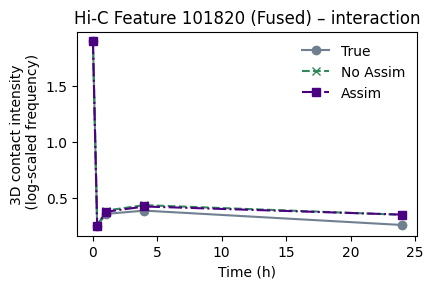

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs(fig_dir, exist_ok=True)

def plot_curve(y_true, y_no, y_as, times, ylabel, title, savepath, colors):
    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(times, y_true, marker='o', color=colors[0], label='True')
    ax.plot(times, y_no, marker='x', linestyle='--', color=colors[1], label='No Assim')
    ax.plot(times, y_as, marker='s', linestyle='-.', color=colors[2], label='Assim')
    ax.set_xlabel('Time (h)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.set_box_aspect(3/5)
    fig.subplots_adjust(left=0.18, right=0.97, top=0.88, bottom=0.20)
    fig.savefig(savepath, dpi=300)
    plt.show()

var_a = X_atac_std.var(axis=0)
idx_a = np.argsort(var_a)[-6:][::-1]

for k, p in enumerate(idx_a):
    plot_curve(
        y_true = X_atac_std[:, p],
        y_no   = X_pred_atac_no[:, p],
        y_as   = X_pred_atac_as[:, p],
        times  = times,
        ylabel = 'Normalized accessibility (z-score)',
        title  = f"ATAC Peak {p} (Fused) – normalized",
        savepath = os.path.join(fig_dir, f"fused_atac_peak_std_{k}_{p}.png"),
        colors = ['#708090', '#000080', '#F08080']
    )

X_atac_true_orig = np.expm1(sc_atac.inverse_transform(X_atac_std))
X_atac_no_orig   = np.expm1(sc_atac.inverse_transform(X_pred_atac_no))
X_atac_as_orig   = np.expm1(sc_atac.inverse_transform(X_pred_atac_as))

for k, p in enumerate(idx_a):
    plot_curve(
        y_true = X_atac_true_orig[:, p],
        y_no   = X_atac_no_orig[:, p],
        y_as   = X_atac_as_orig[:, p],
        times  = times,
        ylabel = 'Chromatin accessibility\n (log-scaled count)',
        title  = f"ATAC Peak {p} (Fused) – accessibility",
        savepath = os.path.join(fig_dir, f"fused_atac_peak_orig_{k}_{p}.png"),
        colors = ['#708090', '#000080', '#F08080']
    )

var_h = X_hic_std.var(axis=0)
idx_h = np.argsort(var_h)[-6:][::-1]

for k, p in enumerate(idx_h):
    plot_curve(
        y_true = X_hic_std[:, p],
        y_no   = X_pred_hic_no[:, p],
        y_as   = X_pred_hic_as[:, p],
        times  = times,
        ylabel = 'Normalized contact strength (z-score)',
        title  = f"Hi-C Feature {p} (Fused) – normalized",
        savepath = os.path.join(fig_dir, f"fused_hic_feat_std_{k}_{p}.png"),
        colors = ['#708090', '#2E8B57', '#4B0082']
    )

X_hic_true_orig = np.expm1(sc_hic.inverse_transform(X_hic_std))
X_hic_no_orig   = np.expm1(sc_hic.inverse_transform(X_pred_hic_no))
X_hic_as_orig   = np.expm1(sc_hic.inverse_transform(X_pred_hic_as))

for k, p in enumerate(idx_h):
    plot_curve(
        y_true = X_hic_true_orig[:, p],
        y_no   = X_hic_no_orig[:, p],
        y_as   = X_hic_as_orig[:, p],
        times  = times,
        ylabel = '3D contact intensity\n (log-scaled frequency)',
        title  = f"Hi-C Feature {p} (Fused) – interaction",
        savepath = os.path.join(fig_dir, f"fused_hic_feat_orig_{k}_{p}.png"),
        colors = ['#708090', '#2E8B57', '#4B0082']
    )


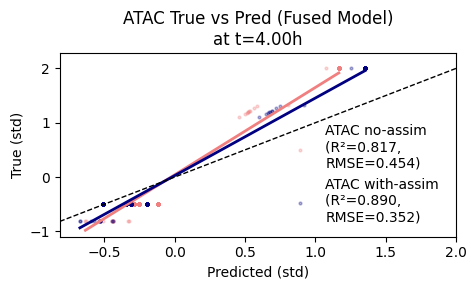

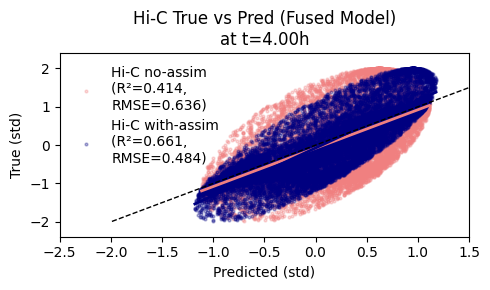

In [25]:
import numpy as np, matplotlib.pyplot as plt, os

t_sel = 3
N = 20000
rng = np.random.default_rng(0)

def rmse(a,b): return np.sqrt(((a-b)**2).mean())
def r2(a,b): return 1 - ((a-b)**2).sum()/((a - a.mean())**2).sum()

# ===== ATAC =====
idx = rng.choice(X_atac_std.shape[1], size=min(N, X_atac_std.shape[1]), replace=False)
y = X_atac_std[t_sel, idx]
x_no = X_pred_atac_no[t_sel, idx]
x_as = X_pred_atac_as[t_sel, idx]
b_no = np.polyfit(x_no, y, 1); line_no = np.poly1d(b_no)
b_as = np.polyfit(x_as, y, 1); line_as = np.poly1d(b_as)

r2_no, r2_as = r2(y, x_no), r2(y, x_as)
rmse_no, rmse_as = rmse(y, x_no), rmse(y, x_as)

xy_min = min(y.min(), x_no.min(), x_as.min())
xy_max = max(y.max(), x_no.max(), x_as.max())

plt.figure(figsize=(5,3))
plt.scatter(x_no, y, s=4, alpha=0.3, color='#F08080', label=f"ATAC no-assim \n(R²={r2_no:.3f}, \nRMSE={rmse_no:.3f})")
plt.plot(np.sort(x_no), line_no(np.sort(x_no)), linewidth=2, color='#F08080')
plt.scatter(x_as, y, s=4, alpha=0.3, color='#000080', label=f"ATAC with-assim \n(R²={r2_as:.3f}, \nRMSE={rmse_as:.3f})")
plt.plot(np.sort(x_as), line_as(np.sort(x_as)), linewidth=2, color='#000080')
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1)
plt.xlim(xy_min, xy_max); plt.ylim(xy_min, xy_max)
plt.xlabel("Predicted (std)")
plt.ylabel("True (std)")
plt.title(f"ATAC True vs Pred (Fused Model)\nat t={times[t_sel]:.2f}h")
plt.ylim(xy_min - 0.1*(xy_max - xy_min), xy_max + 0.1*(xy_max - xy_min))
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"fused_atac_true_vs_pred_t{t_sel}.png"), dpi=300)
plt.show()

# ===== Hi-C =====
idx = rng.choice(X_hic_std.shape[1], size=min(N, X_hic_std.shape[1]), replace=False)
y = X_hic_std[t_sel, idx]
x_no = X_pred_hic_no[t_sel, idx]
x_as = X_pred_hic_as[t_sel, idx]
b_no = np.polyfit(x_no, y, 1); line_no = np.poly1d(b_no)
b_as = np.polyfit(x_as, y, 1); line_as = np.poly1d(b_as)

r2_no, r2_as = r2(y, x_no), r2(y, x_as)
rmse_no, rmse_as = rmse(y, x_no), rmse(y, x_as)

xy_min = min(y.min(), x_no.min(), x_as.min())
xy_max = max(y.max(), x_no.max(), x_as.max())

plt.figure(figsize=(5,3))
plt.scatter(x_no, y, s=4, alpha=0.3, color='#F08080', label=f"Hi-C no-assim \n(R²={r2_no:.3f}, \nRMSE={rmse_no:.3f})")
plt.plot(np.sort(x_no), line_no(np.sort(x_no)), linewidth=2, color='#F08080')
plt.scatter(x_as, y, s=4, alpha=0.3, color='#000080', label=f"Hi-C with-assim \n(R²={r2_as:.3f}, \nRMSE={rmse_as:.3f})")
plt.plot(np.sort(x_as), line_as(np.sort(x_as)), linewidth=2, color='#000080')
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1)
plt.xlim(-2.5, 1.5); plt.ylim(xy_min, xy_max)
plt.ylim(xy_min - 0.1*(xy_max - xy_min), xy_max + 0.1*(xy_max - xy_min))
plt.xlabel("Predicted (std)")
plt.ylabel("True (std)")
plt.title(f"Hi-C True vs Pred (Fused Model)\nat t={times[t_sel]:.2f}h")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"fused_hic_true_vs_pred_t{t_sel}.png"), dpi=300)
plt.show()


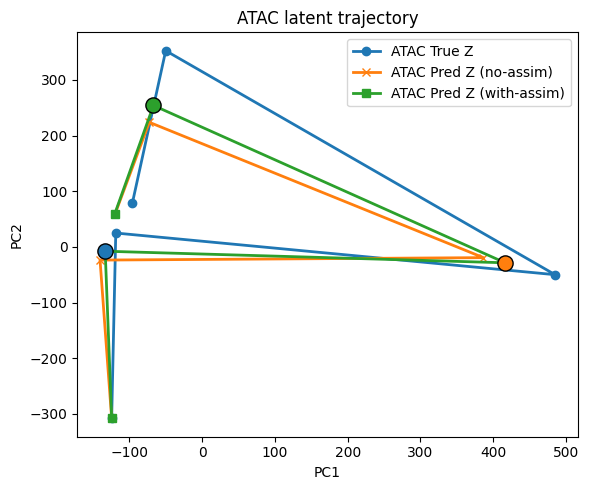

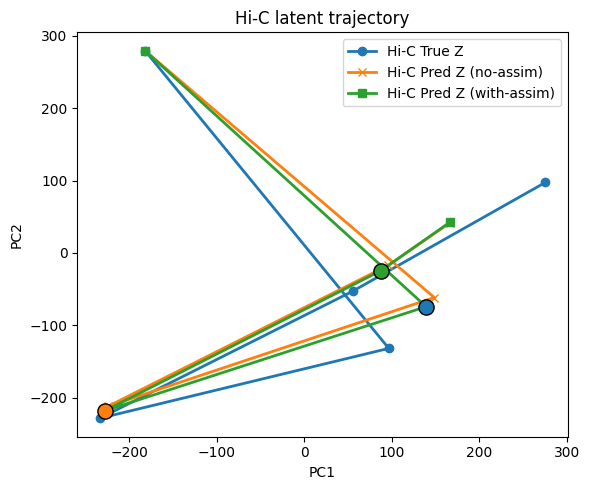

In [6]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# project predicted back to latent (per modality)
Z_atac_no = pca_atac.transform(X_pred_atac_no)
Z_atac_as = pca_atac.transform(X_pred_atac_as)
Z_hic_no  = pca_hic.transform(X_pred_hic_no)
Z_hic_as  = pca_hic.transform(X_pred_hic_as)

# ATAC 2D projection
A = np.vstack([Z_true_atac, Z_atac_no, Z_atac_as])
p2a = PCA(n_components=2, random_state=0).fit(A)
T_true_a = p2a.transform(Z_true_atac)
T_no_a   = p2a.transform(Z_atac_no)
T_as_a   = p2a.transform(Z_atac_as)

plt.figure(figsize=(6,5))
plt.plot(T_true_a[:,0], T_true_a[:,1], marker='o', linewidth=2, label='ATAC True Z')
plt.plot(T_no_a[:,0],   T_no_a[:,1],   marker='x', linewidth=2, label='ATAC Pred Z (no-assim)')
plt.plot(T_as_a[:,0],   T_as_a[:,1],   marker='s', linewidth=2, label='ATAC Pred Z (with-assim)')
for ai in assim_idx:
    plt.scatter(T_as_a[ai,0], T_as_a[ai,1], s=120, edgecolor='black', zorder=5)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("ATAC latent trajectory")
plt.legend(); plt.tight_layout(); plt.show()

# Hi-C 2D projection
H = np.vstack([Z_true_hic, Z_hic_no, Z_hic_as])
p2h = PCA(n_components=2, random_state=0).fit(H)
T_true_h = p2h.transform(Z_true_hic)
T_no_h   = p2h.transform(Z_hic_no)
T_as_h   = p2h.transform(Z_hic_as)

plt.figure(figsize=(6,5))
plt.plot(T_true_h[:,0], T_true_h[:,1], marker='o', linewidth=2, label='Hi-C True Z')
plt.plot(T_no_h[:,0],   T_no_h[:,1],   marker='x', linewidth=2, label='Hi-C Pred Z (no-assim)')
plt.plot(T_as_h[:,0],   T_as_h[:,1],   marker='s', linewidth=2, label='Hi-C Pred Z (with-assim)')
for ai in assim_idx:
    plt.scatter(T_as_h[ai,0], T_as_h[ai,1], s=120, edgecolor='black', zorder=5)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Hi-C latent trajectory")
plt.legend(); plt.tight_layout(); plt.show()


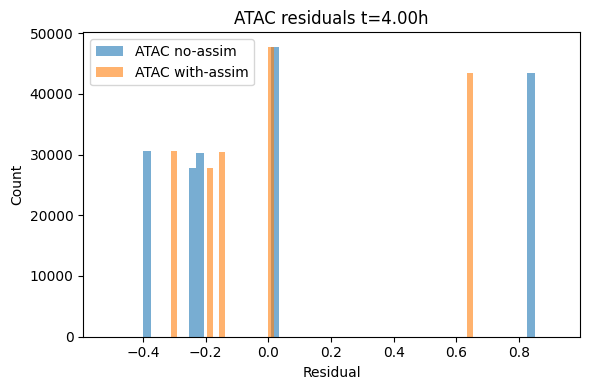

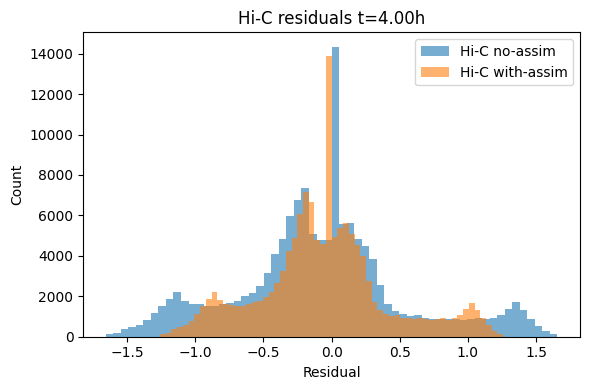

In [8]:
import numpy as np, matplotlib.pyplot as plt

t_sel = 3

res_no = X_atac_std[t_sel] - X_pred_atac_no[t_sel]
res_as = X_atac_std[t_sel] - X_pred_atac_as[t_sel]
plt.figure(figsize=(6,4))
plt.hist(res_no, bins=60, alpha=0.6, label="ATAC no-assim")
plt.hist(res_as, bins=60, alpha=0.6, label="ATAC with-assim")
plt.xlabel("Residual"); plt.ylabel("Count"); plt.title(f"ATAC residuals t={times[t_sel]:.2f}h")
plt.legend(); plt.tight_layout(); plt.show()

res_no = X_hic_std[t_sel] - X_pred_hic_no[t_sel]
res_as = X_hic_std[t_sel] - X_pred_hic_as[t_sel]
plt.figure(figsize=(6,4))
plt.hist(res_no, bins=60, alpha=0.6, label="Hi-C no-assim")
plt.hist(res_as, bins=60, alpha=0.6, label="Hi-C with-assim")
plt.xlabel("Residual"); plt.ylabel("Count"); plt.title(f"Hi-C residuals t={times[t_sel]:.2f}h")
plt.legend(); plt.tight_layout(); plt.show()


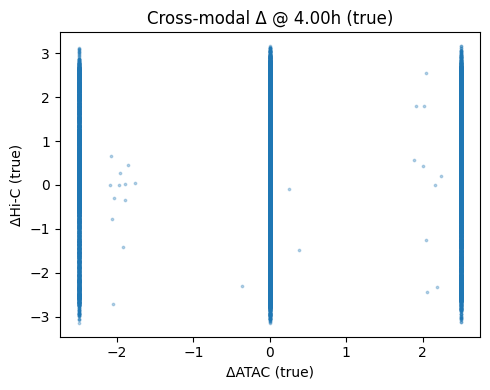

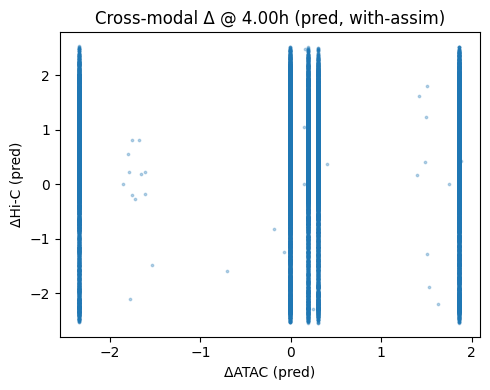

In [9]:
import numpy as np, matplotlib.pyplot as plt

def delta_vs_baseline(X):
    return X - X[0:1]

# choose 4h or 24h
t_sel = np.argmin(np.abs(times - 4.0))

d_atac_true = delta_vs_baseline(X_atac_std)[t_sel]
d_hic_true  = delta_vs_baseline(X_hic_std)[t_sel]
d_atac_pred = delta_vs_baseline(X_pred_atac_as)[t_sel]  # with assimilation
d_hic_pred  = delta_vs_baseline(X_pred_hic_as)[t_sel]

# subsample for scatter
N = 30000
rng = np.random.default_rng(1)
idx_a = rng.choice(d_atac_true.shape[0], size=min(N, d_atac_true.shape[0]), replace=False)
idx_h = rng.choice(d_hic_true.shape[0],  size=min(N, d_hic_true.shape[0]),  replace=False)

# True cross-modal
plt.figure(figsize=(5,4))
plt.scatter(d_atac_true[idx_a], d_hic_true[idx_h][:idx_a.size], s=3, alpha=0.3)
plt.xlabel("ΔATAC (true)"); plt.ylabel("ΔHi-C (true)")
plt.title(f"Cross-modal Δ @ {times[t_sel]:.2f}h (true)")
plt.tight_layout(); plt.show()

# Pred cross-modal
plt.figure(figsize=(5,4))
plt.scatter(d_atac_pred[idx_a], d_hic_pred[idx_h][:idx_a.size], s=3, alpha=0.3)
plt.xlabel("ΔATAC (pred)"); plt.ylabel("ΔHi-C (pred)")
plt.title(f"Cross-modal Δ @ {times[t_sel]:.2f}h (pred, with-assim)")
plt.tight_layout(); plt.show()


In [10]:
bl_fused = np.tile(X_true_fused[0], (len(times), 1))
print("baseline_rmse_std", rmse(X_true_fused, bl_fused), "r2", r2(X_true_fused, bl_fused))
print("no_assim_rmse_std", rmse(X_true_fused, X_no_fused), "r2", r2(X_true_fused, X_no_fused))
print("with_assim_rmse_std", rmse(X_true_fused, X_as_fused), "r2", r2(X_true_fused, X_as_fused))

err_no = np.sqrt(((X_true_fused - X_no_fused)**2).mean(axis=1))
err_as = np.sqrt(((X_true_fused - X_as_fused)**2).mean(axis=1))
for i, tt in enumerate(times):
    print(f"time {tt:.2f}h no-assim {err_no[i]:.4f} with-assim {err_as[i]:.4f}")


baseline_rmse_std 1.3566929 r2 -0.8953832387924194
no_assim_rmse_std 0.40144753 r2 0.8340445458889008
with_assim_rmse_std 0.3433505 r2 0.8786026239395142
time 0.00h no-assim 0.0001 with-assim 0.0001
time 0.33h no-assim 0.4422 with-assim 0.3513
time 1.00h no-assim 0.2059 with-assim 0.1425
time 4.00h no-assim 0.5422 with-assim 0.4153
time 24.00h no-assim 0.5234 with-assim 0.5227
